# A GPS-only agent that finds where a haul fleet loses time

*Baruun Naran, load zone 25559. Rebuilt 2026-08-07.*

The question this notebook is trying to answer is not "how fast is this mine" but **can a piece
of software, given nothing but GPS pings, work out how the mine actually operates and then say
what to fix?**

The chain is: **raw GPS → cycles → discover the loop's topology → account for every minute →
rank the levers**. No step needs a human to say what a place is for, which matters, because we
have no site contact and a hard-coded list of one mine's Mongolian place names would not
transfer anywhere else.

Two things worth knowing before the numbers:

**What we got wrong before.** The earlier version ranked *"fix the empty-return road"* as the #1
lever at +16 loads/day. It was an artefact. `return_s` is one timestamp minus another, so
anything the truck did in between — a shift handover, a weighbridge, a tarping point, queueing
outside the pit gate — was invisible and got charged to the road. Only **56%** of "road" time is
a truck driving. Once separated, the empty-return road drops to **#8 (+1.6/day)**, in every one
of the five months.

**What we are not claiming.** The headline is reported as a range, not a point, because the data
cannot locate a point. Every hand-set number is named below, and the ones that could change an
answer have been swept.

In [1]:
import sys, os, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import agent_v2 as A

ZONE, MONTH = 25559, '2025-11'
MONTHS = ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11']
TEAL, ORANGE, BLUE, GREY, RED = '#1b9e8a', '#e6820a', '#3b6ea5', '#9aa0a6', '#c0392b'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('ok')

ok


## 1 — Building the loop from raw pings

`build_cycles(month)` takes a month of GPS it has never seen, joins each ping to the mine's
material-zone polygons, collapses consecutive pings in one zone into a visit, and reads off
`load → unload → load` cycles. Cycles longer than 6 h are dropped as offline gaps or shift
breaks.

Everything downstream runs on this table, so having it *inside* the agent — rather than
depending on a pre-baked CSV — is what lets us hand the thing a new month.

In [2]:
cyc = A.load_cycles(ZONE, MONTH)          # builds from raw GPS if the month is unknown
cut = round(A.mlt.robust_queue_cut(cyc['dwell_s'].dropna()/60), 1)
print(f"{len(cyc)} cycles | {cyc.tracker_id.nunique()} trucks | {cyc.date.nunique()} days "
      f"| GMM dwell cut {cut} min")
cyc[['tracker_id','depart_load','arrive_unload','depart_unload','arrive_load',
     'haul_s','dump_s','return_s','cycle_s']].head(3)

2417 cycles | 22 trucks | 30 days | GMM dwell cut 147.6 min


,tracker_id,depart_load,arrive_unload,depart_unload,arrive_load,haul_s,dump_s,return_s,cycle_s
0,20505,2025-11-05 20:45:04,2025-11-05 21:54:01,2025-11-05 21:54:01,2025-11-05 23:05:12,4137.0,0.0,4271.0,8408.0
1,20505,2025-11-05 23:29:55,2025-11-06 00:47:40,2025-11-06 01:03:15,2025-11-06 01:51:02,4665.0,935.0,2867.0,8467.0
2,20505,2025-11-06 02:10:05,2025-11-06 03:16:47,2025-11-06 03:20:25,2025-11-06 04:06:51,4002.0,218.0,2786.0,7006.0


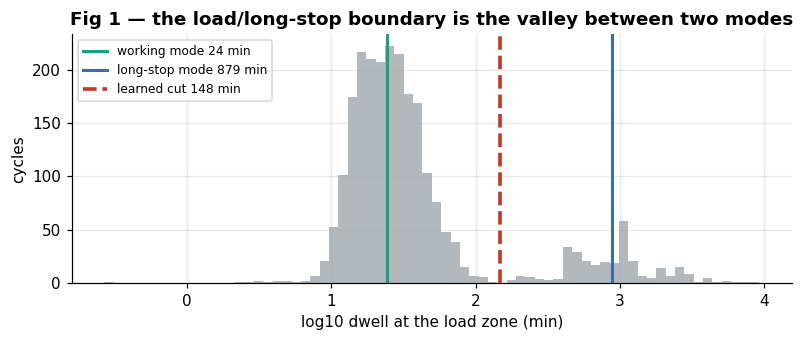

In [3]:
d = cyc['dwell_s'].dropna()/60
work, park, w_work, _ = A.mlt.fit_two_modes(d)
fig, ax = plt.subplots(figsize=(7.4, 3.2))
ax.hist(np.log10(d), bins=70, color=GREY, alpha=.75)
for x, lab, c in [(work, f'working mode {work:.0f} min', TEAL),
                  (park, f'long-stop mode {park:.0f} min', BLUE)]:
    ax.axvline(np.log10(x), color=c, lw=2, label=lab)
ax.axvline(np.log10(cut), color=RED, lw=2.4, ls='--', label=f'learned cut {cut:.0f} min')
ax.set_xlabel('log10 dwell at the load zone (min)'); ax.set_ylabel('cycles')
ax.set_title('Fig 1 — the load/long-stop boundary is the valley between two modes',
             fontweight='bold'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('v4_fig1_gmm.png', dpi=130)

## 2 — Discovering the topology: what is a station, what is just a place we drive past

This is the step that replaces our judgement with a measurement. For every zone the mine has
drawn, we ask two questions of the GPS:

1. **Does every trip pass here?** `coverage = visits / cycles`. A place passed on both legs of
   every trip scores ~200%.
2. **Do trucks actually stop here?** the share of visits containing a ping at ≤2 km/h.

Coverage alone is not enough — junctions and mileposts also score ~200%, because every truck
*drives through* them. The second question separates them, and it separates them cleanly:

| | coverage | stop rate | median dwell |
|---|---|---|---|
| weighbridges, tarping points, pit gate | 199–213% | **0.91–0.97** | 3–8 min |
| junctions, mileposts, pass-throughs | 173–202% | **0.00–0.14** | 0.2–1.4 min |

Nothing lands between 0.23 and 0.89, so the 0.5 cut we use is inert — anywhere in that gap gives
the identical answer.

A place **below 100% coverage** has to leave the loop entirely. This is not fussiness: if only
16% of trips stop at the car park, the p15 leg baseline contains no such stop, so leaving it in
would book the whole shift handover as road waste.

Finally, zones whose boxes overlap are merged — the tarping-off point and the Ukhaa weighbridge
are ~100 m apart, and to a truck they are one queue. (Merging is applied *only among stations*;
merging across all zones chains the whole dump-side industrial area into one blob.)

In [4]:
pings = A.load_pings(MONTH, cyc.tracker_id.unique())
stations, offloop, topo = A.discover_topology(cyc, pings)
topo.head(14)

,zone_id,label,visits,coverage_pct,stop_rate,kind,members
19,27928,Баруун наран ачилтруу оролт,5143,213,0.91,station,1
22,27840,Баруун наран пүү/Ухаа/,5138,213,0.94,station,1
3,27839,БН-Хучлаг авах цэг,5106,211,0.91,station,1
20,29193,S30 Овоолго,4893,202,0.00,waypoint,1
1,25561,БН-Хучлаг хучих цэг,4831,200,0.97,station,1
6,28605,эргэлт 1,4818,199,0.05,waypoint,1
7,25560,Баруун наран пүү /БН/,4801,199,0.92,station,1
24,28867,цанхи уулзвар,4805,199,0.00,waypoint,1
11,28607,эргэлт3,4808,199,0.02,waypoint,1
12,28606,эргэлт2,4816,199,0.05,waypoint,1


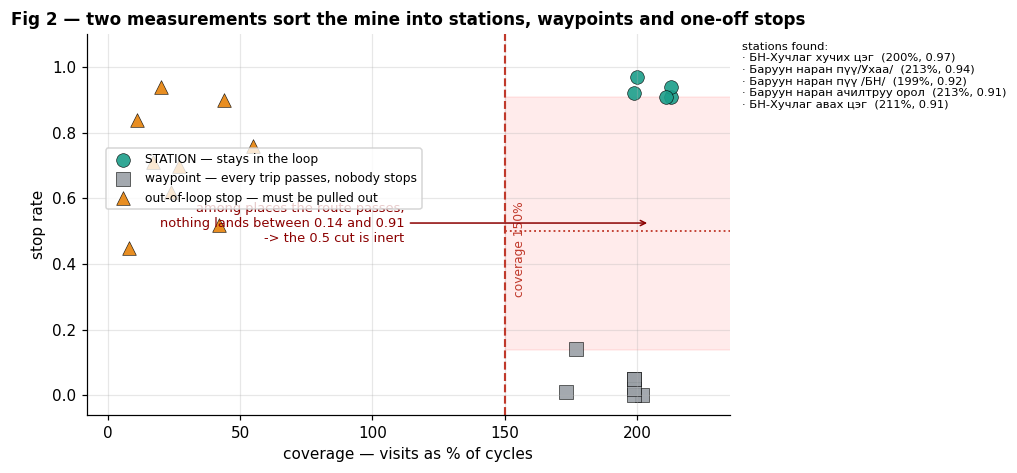

In [5]:
from matplotlib.patches import Rectangle
T = topo[topo.visits >= 200].copy()
onroute = T[T.coverage_pct >= A.STATION_MIN_COV]          # the gap claim holds HERE only —
hi = onroute[onroute.kind == 'station'].stop_rate.min()   # off-loop stops do sit in between,
lo = onroute[onroute.kind == 'waypoint'].stop_rate.max()  # but they are excluded by coverage
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.add_patch(Rectangle((A.STATION_MIN_COV, lo), 240 - A.STATION_MIN_COV, hi - lo,
                       color='red', alpha=.08, zorder=0))
ax.plot([A.STATION_MIN_COV, 240], [A.STATION_MIN_STOPRATE] * 2, ls=':', color=RED, lw=1.2)
ax.axvline(A.STATION_MIN_COV, color=RED, ls='--', lw=1.4)
kinds = {'station': (TEAL, 'o', 'STATION — stays in the loop'),
         'waypoint': (GREY, 's', 'waypoint — every trip passes, nobody stops'),
         'offloop': (ORANGE, '^', 'out-of-loop stop — must be pulled out'),
         'ambiguous': (BLUE, 'x', 'ambiguous')}
for k, (c, mk, lb) in kinds.items():
    s = T[T.kind == k]
    if not len(s): continue
    ax.scatter(s.coverage_pct, s.stop_rate, c=c, marker=mk, s=80, label=lb, alpha=.9,
               edgecolors='k', linewidths=.4)
ax.text(A.STATION_MIN_COV + 3, .30, f'coverage {A.STATION_MIN_COV}%', color=RED, fontsize=8,
        rotation=90, va='bottom')
ax.annotate(f'among places the route passes,\nnothing lands between {lo:.2f} and {hi:.2f}\n'
            f'-> the {A.STATION_MIN_STOPRATE} cut is inert',
            xy=(205, (lo + hi) / 2), xytext=(112, (lo + hi) / 2), fontsize=8.5, color='darkred',
            va='center', ha='right',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1))
# stations sit on top of each other; list them instead of annotating in place
names = [f"{r.label.split('+')[0].strip()[:26]}  ({r.coverage_pct}%, {r.stop_rate:.2f})"
         for _, r in T[T.kind == 'station'].sort_values('stop_rate', ascending=False).iterrows()]
ax.text(1.02, .98, 'stations found:\n' + '\n'.join('· ' + n for n in names),
        transform=ax.transAxes, fontsize=7.5, va='top', family='DejaVu Sans')
ax.set_xlabel('coverage — visits as % of cycles'); ax.set_ylabel('stop rate')
ax.set_ylim(-.06, 1.10); ax.set_xlim(-8, 235)
ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(.02, .62))
ax.set_title('Fig 2 — two measurements sort the mine into stations, waypoints and one-off stops',
             fontweight='bold', fontsize=11)
fig.tight_layout(); fig.savefig('v4_fig2_topology.png', dpi=130, bbox_inches='tight')

In [6]:
print('STATIONS (merged complexes, stay in the loop):')
for s in stations:
    print(f"   {s['coverage_pct']:3d}%  stop {s['stop_rate']:.2f}   {s['label']}")
print('\nOUT-OF-LOOP (pulled out; a dispatcher cannot recover a shift handover):')
for o in offloop[:6]:
    print(f"   {o['coverage_pct']:3d}%  stop {o['stop_rate']:.2f}   {o['label']}")
print('\nWAYPOINTS (every trip passes, nobody stops -> their time is DRIVING):')
for _, r in topo[topo.kind == 'waypoint'].head(7).iterrows():
    print(f"   {r.coverage_pct:3d}%  stop {r.stop_rate:.2f}   {r.label}")

STATIONS (merged complexes, stay in the loop):
   213%  stop 0.94   Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг
   213%  stop 0.91   Баруун наран ачилтруу оролт + Баруун наран пүү /БН/ + БН-Хучлаг хучих цэг

OUT-OF-LOOP (pulled out; a dispatcher cannot recover a shift handover):
    55%  stop 0.76   Sp3
    44%  stop 0.90   baruun hard
    42%  stop 0.52   Баруун наран клонк
    27%  stop 0.70   hard 3
    24%  stop 0.62   buulgalt
    20%  stop 0.94   Режектийн зам

WAYPOINTS (every trip passes, nobody stops -> their time is DRIVING):
   202%  stop 0.00   S30 Овоолго
   199%  stop 0.05   эргэлт 1
   199%  stop 0.00   цанхи уулзвар
   199%  stop 0.02   эргэлт3
   199%  stop 0.05   эргэлт2
   177%  stop 0.14   ТЛ замын ачилт
   173%  stop 0.01   SP11


## 3 — Where the minutes actually go

Every GPS interval inside a haul or return leg is charged to exactly one place (smallest
containing box wins), or to *driving* / *stopped-somewhere-unmapped* if it is in no zone. The
identity closes to under 1%, and the classification survives an independent check: during the
intervals we call "stopped", the odometer advances at **0.3 km/h**; during "driving", 35.4 km/h.

In [7]:
boxes = list(stations) + list(offloop)
R = A.decompose_legs(cyc, pings, boxes)
share = (R.drop(columns=['leg','total']).sum()/60).sort_values(ascending=False)
lab = {b['name']: b['label'][:34] for b in boxes}
lab.update(driving='DRIVING', stopped_unmapped='stopped, unmapped')
print(f"leg time {R.total.sum()/60:.0f} truck-h, accounted "
      f"{100*(share.sum()-R.total.sum()/60)/(R.total.sum()/60):+.1f}%\n")
for k, v in share.items():
    print(f"   {lab.get(k,k):36s} {v:6.0f} h   {100*v/share.sum():5.1f}%")

leg time 6566 truck-h, accounted -0.8%

   DRIVING                                3618 h    55.5%
   Баруун наран пүү/Ухаа/ + БН-Хучлаг      990 h    15.2%
   Баруун наран ачилтруу оролт + Бару      917 h    14.1%
   stopped, unmapped                       405 h     6.2%
   БН шинэ паркын талбай                   287 h     4.4%
   Sp3                                     155 h     2.4%
   Баруун наран клонк                       97 h     1.5%
   2-р км                                   30 h     0.5%
   baruun hard                               7 h     0.1%
   Terminal Middling овоолго                 5 h     0.1%
   ER клонк                                  1 h     0.0%
   мидлинг буулгалт                          1 h     0.0%
   hard 3                                    1 h     0.0%
   Режектийн зам                             0 h     0.0%


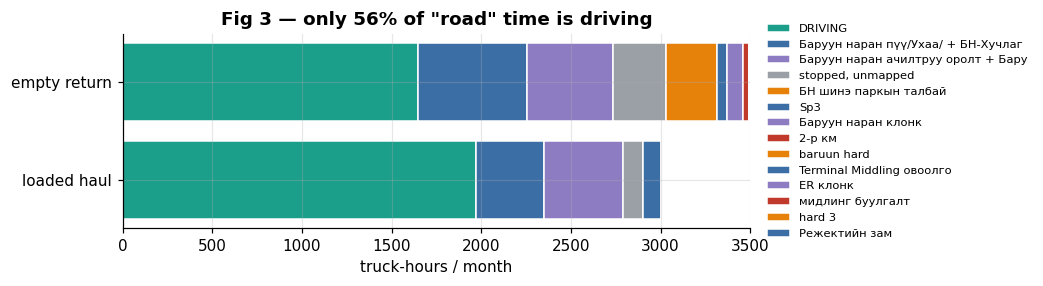

In [8]:
order = list(share.index)
fig, ax = plt.subplots(figsize=(9.6, 2.7))
cols = [TEAL if o == 'driving' else GREY if o == 'stopped_unmapped'
        else [ORANGE, BLUE, '#8e7cc3', RED][i % 4] for i, o in enumerate(order)]
for legname, y in [('haul', 'loaded haul'), ('ret', 'empty return')]:
    left = 0
    for i, o in enumerate(order):
        v = R[R.leg == legname][o].sum()/60
        ax.barh(y, v, left=left, color=cols[i], edgecolor='w',
                label=lab.get(o, o) if legname == 'haul' else None)
        left += v
dp = 100*R['driving'].sum()/R.drop(columns=['leg','total']).sum().sum()
ax.set_xlabel('truck-hours / month')
ax.legend(fontsize=7.5, ncol=1, loc='center left', bbox_to_anchor=(1.01, .5), frameon=False)
ax.set_title(f'Fig 3 — only {dp:.0f}% of "road" time is driving', fontweight='bold')
fig.tight_layout(); fig.savefig('v4_fig3_legs.png', dpi=130, bbox_inches='tight')

### Splitting a station's time without inventing another percentile

For each visit we count how many other trucks were already inside on arrival.

* **service** = min(dwell, *median dwell when nobody else was there*) — measured, not chosen
* **queue** = the excess when ≥1 truck was already there
* **solo-long** = the excess with nobody there. We refuse to put this in either bucket; its
  cause is unknown (a breakdown, a break, a tarp that went wrong) and pretending otherwise
  would either inflate the service time or invent a queue.

The check that licenses reading the middle one as a queue is that dwell must rise with
concurrency. It does — though more weakly than at the shovel (Spearman ≈0.2 vs 0.35), so it is
evidence, not proof.

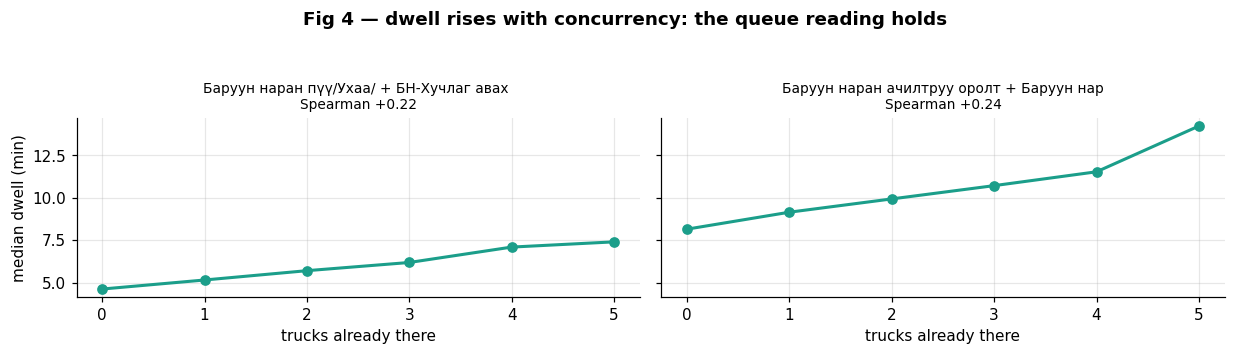

In [9]:
fig, axes = plt.subplots(1, len(stations), figsize=(5.6*len(stations), 3.0), sharey=True)
axes = np.atleast_1d(axes)
for ax, b in zip(axes, stations):
    V = A._visits(pings, b)
    g = V.groupby(V.conc.clip(upper=5))['min'].median()
    ax.plot(g.index, g.values, 'o-', color=TEAL, lw=2)
    r = V[['conc','min']].corr(method='spearman').iloc[0,1]
    ax.set_title(f"{b['label'][:40]}\nSpearman {r:+.2f}", fontsize=9)
    ax.set_xlabel('trucks already there')
axes[0].set_ylabel('median dwell (min)')
fig.suptitle('Fig 4 — dwell rises with concurrency: the queue reading holds', fontweight='bold', y=1.06)
fig.tight_layout(); fig.savefig('v4_fig4_conc.png', dpi=130, bbox_inches='tight')

## 4 — The diagnosis, and what changed

In [10]:
dx = A.diagnose_v2(ZONE, MONTH, with_band=False)
print(A.report(dx))

DIAGNOSIS v2 — BN load (Баруун наран /Зүүн/) (zone 25559, 2025-11)
THROUGHPUT : 80.6 loads/day | 22 trucks | 22h active/day
GMM cut    : 147.6 min  (loading/queue <-> long stop)
METHOD     : ping layer: six stations, causal service times
STATIONS   : shovel 7.3/h busy 50% | dump 8.3/h busy 44%  -> binding = SHOVEL  (not saturated)
             loop 232.2 min | cycling 312 truck-h/day
ROAD LEGS  : only 56% of 'road' time is actually driving (accounting closes to -0.8%)

ROADSIDE STATIONS (every trip passes these, both ways):
   station                         total service  queue solo-long  svc min  conc r
   Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг    990     343    583        64      4.6    0.22
   Баруун наран ачилтруу оролт + Баруун наран пүү /БН/ + БН-Хучлаг хучих цэг    917     520    368        28      8.2    0.24

IN-LOOP WASTE (truck-h/mo, by CAUSE):
   queue_shovel               1374 h
   dump                        634 h
   z27840_27839_queue          583 h
   stopped_unma

The flip is not a parameter choice — it comes from separating time a truck spent *stopped* from
time it spent *driving*, which the cycle table cannot see at all.

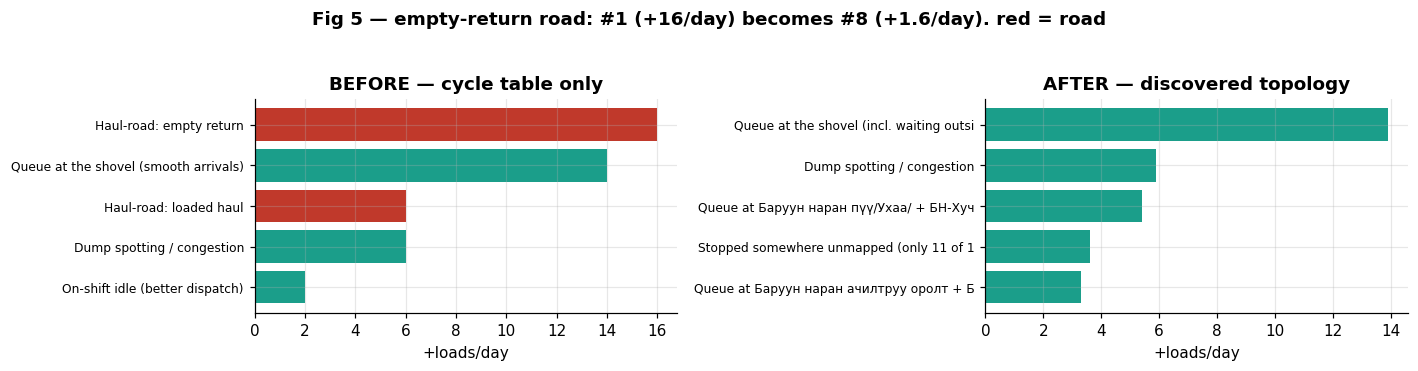

In [11]:
old = A.diagnose_v2(ZONE, MONTH, with_band=False, use_pings=False)
pairs = [([(l['cause'][:40], l['gain']) for l in old['levers'][:5]], 'BEFORE — cycle table only'),
         ([(l['cause'][:40], l['gain']) for l in dx['levers'][:5]], 'AFTER — discovered topology')]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
for a_, (dat, t) in zip(ax, pairs):
    labs = [x[0] for x in dat][::-1]; val = [x[1] for x in dat][::-1]
    cols = [RED if ('road' in l.lower() or 'Haul-road' in l) else TEAL for l in labs]
    a_.barh(range(len(labs)), val, color=cols)
    a_.set_yticks(range(len(labs))); a_.set_yticklabels(labs, fontsize=8)
    a_.set_title(t, fontweight='bold'); a_.set_xlabel('+loads/day')
rr = [l['rank'] for l in dx['levers'] if l['key'] == 'road_return'][0]
fig.suptitle(f'Fig 5 — empty-return road: #1 (+16/day) becomes #{rr} (+{[l["gain"] for l in dx["levers"] if l["key"]=="road_return"][0]}/day). red = road',
             fontweight='bold', y=1.04)
fig.tight_layout(); fig.savefig('v4_fig5_flip.png', dpi=130, bbox_inches='tight')

## 5 — A recommendation per month

Same code, five months, nothing tuned in between. The agent also says whether its #1 is a real
winner or a tie: ranks only ever swap when #1 and #2 sit within a few loads/day of each other,
so below that margin it refuses to name a single winner.

In [12]:
rows = []
for m in MONTHS:
    d = A.diagnose_v2(ZONE, m, with_band=False)
    rr = [l for l in d['levers'] if l['key'] == 'road_return'][0]
    qs = [l for l in d['levers'] if l['key'] == 'queue_shovel'][0]
    rows.append(dict(month=m, loads_day=d['throughput']['loads_day'],
                     rho_shovel=d['stations']['rho_shovel'], saturated=d['stations']['saturated'],
                     stations_found=len(d['roadside_stations']),
                     driving_pct=d['leg_decomposition']['driving_share_pct'],
                     top_lever=d['levers'][0]['cause'][:34], margin=d['lever_verdict']['margin'],
                     tied=d['lever_verdict']['tied'],
                     shovel_queue_rank=qs['rank'], road_return_rank=rr['rank'],
                     floor_pct=d['headline']['lower_bound_pct'],
                     ceil_pct=d['headline']['upper_bound_pct']))
M = pd.DataFrame(rows); M.to_csv('v4_five_months.csv', index=False)
M

,month,loads_day,rho_shovel,saturated,stations_found,driving_pct,top_lever,margin,tied,shovel_queue_rank,road_return_rank,floor_pct,ceil_pct
0,2025-07,48.5,0.43,False,2,56,On-shift idle (better dispatch),0.2,True,3,7,33,80
1,2025-08,78.0,0.52,False,2,58,Queue at Баруун наран пүү/Ухаа/ +,0.9,True,2,8,26,78
2,2025-09,77.6,0.53,False,2,57,Queue at the shovel (incl. waiting,3.2,True,1,8,27,68
3,2025-10,88.3,0.59,False,2,57,Queue at the shovel (incl. waiting,10.1,False,1,8,26,70
4,2025-11,80.6,0.50,False,2,56,Queue at the shovel (incl. waiting,8.0,False,1,8,21,75


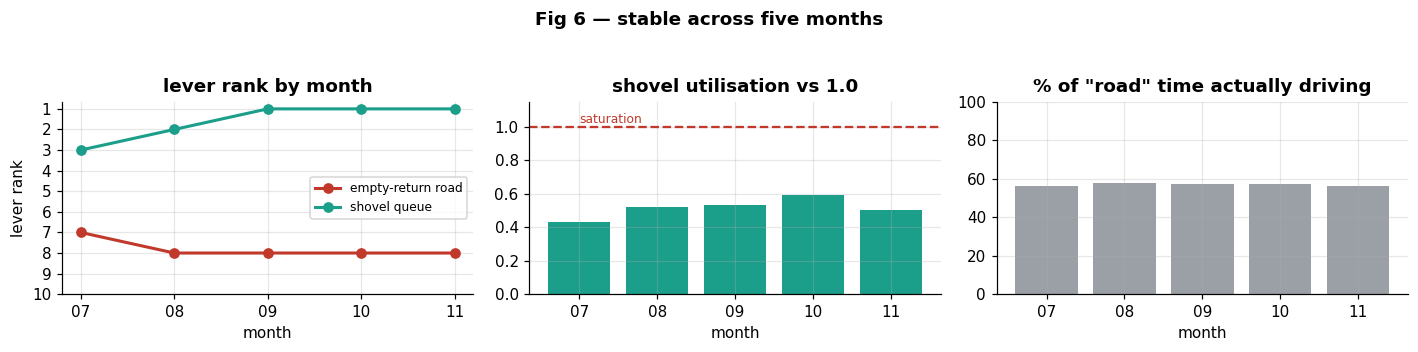

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.0))
x = range(len(M))
ax[0].plot(x, M.road_return_rank, 'o-', color=RED, lw=2, label='empty-return road')
ax[0].plot(x, M.shovel_queue_rank, 'o-', color=TEAL, lw=2, label='shovel queue')
ax[0].invert_yaxis(); ax[0].set_yticks(range(1, 11)); ax[0].set_ylabel('lever rank')
ax[0].legend(fontsize=8); ax[0].set_title('lever rank by month', fontweight='bold')
ax[1].bar(x, M.rho_shovel, color=TEAL); ax[1].axhline(1.0, color=RED, ls='--')
ax[1].text(0, 1.02, 'saturation', color=RED, fontsize=8); ax[1].set_ylim(0, 1.15)
ax[1].set_title('shovel utilisation vs 1.0', fontweight='bold')
ax[2].bar(x, M.driving_pct, color=GREY); ax[2].set_ylim(0, 100)
ax[2].set_title('% of "road" time actually driving', fontweight='bold')
for a_ in ax:
    a_.set_xticks(list(x)); a_.set_xticklabels([m[-2:] for m in M.month]); a_.set_xlabel('month')
fig.suptitle('Fig 6 — stable across five months', fontweight='bold', y=1.05)
fig.tight_layout(); fig.savefig('v4_fig6_months.png', dpi=130, bbox_inches='tight')

### The headline is a range

The old single figure compared a *contaminated* "now" — the monthly mean quietly includes real
stoppage days — against a ceiling never once approached in 150 days. Both ends were wrong in the
same direction.

* **Floor**: every normal day matches this fleet's *own best day*. No baseline quantile, no
  service rate, no extrapolation — it happened. It is a lower bound, and weak in one specific
  way: it measures day-to-day *inconsistency*, so a uniformly slow mine would score +0% and
  still have plenty to gain.
* **Ceiling**: all in-loop waste removed at once. Never observed, and it leans on a capacity
  figure that moves 125–273 loads/day under plausible parameters.

We report both and claim neither as the answer.

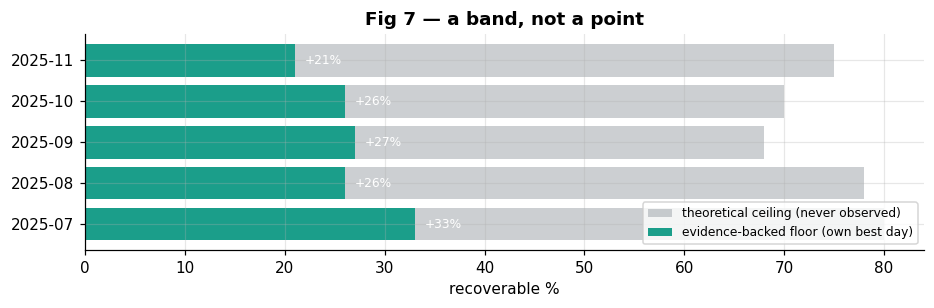

In [14]:
fig, ax = plt.subplots(figsize=(8.6, 2.9))
y = range(len(M))
ax.barh(y, M.ceil_pct, color=GREY, alpha=.5, label='theoretical ceiling (never observed)')
ax.barh(y, M.floor_pct, color=TEAL, label='evidence-backed floor (own best day)')
for i, r in M.iterrows():
    ax.text(r.floor_pct+1, i, f"+{r.floor_pct}%", va='center', fontsize=8,
            color='white' if r.floor_pct > 12 else 'black')
ax.set_yticks(list(y)); ax.set_yticklabels(M.month); ax.set_xlabel('recoverable %')
ax.legend(fontsize=8, loc='lower right')
ax.set_title('Fig 7 — a band, not a point', fontweight='bold')
fig.tight_layout(); fig.savefig('v4_fig7_range.png', dpi=130)

In [15]:
o = dx['observed']
print(f"BN {MONTH}: {o['normal_days']} normal days, {o['stoppage_days']} stoppage days")
print(f"  now {o['current_loads_day']}/day -> own best day {o['best_day']} = +{o['gain_pct_best']}%")
print(f"  split: more trucks out +{o['from_more_trucks_pct']}% (maintenance) | "
      f"trips per truck +{o['from_trips_per_truck_pct']}% (dispatch)")
print(f"  stoppage days cost {o['stoppage_lost_loads']} loads = "
      f"{o['stoppage_lost_share_pct']}% of the month")

BN 2025-11: 26 normal days, 4 stoppage days
  now 90.1/day -> own best day 109 = +21%
  split: more trucks out +8% (maintenance) | trips per truck +10% (dispatch)
  stoppage days cost 285 loads = 12% of the month


## 6 — Reusability: hand it a month it has never seen

The claim only means something if it is tested. Below we delete November from the pre-baked
cycle table, so the agent has to rebuild the cycles from raw GPS, rediscover the topology, and
re-derive the recommendation with no human in the loop. A December file would take exactly this
path.

In [16]:
import copy, time
saved = A._CYCLES
A._CYCLES = A._cycles_df().copy()
A._CYCLES = A._CYCLES[A._CYCLES.month != MONTH]
print('cycle table now holds:', sorted(A._CYCLES.month.unique()), '\n')
t0 = time.time()
fresh = A.diagnose_v2(ZONE, MONTH, with_band=False)
print(f"rebuilt from raw GPS in {time.time()-t0:.0f}s")
print(f"  cycles           {fresh['throughput']}")
print(f"  stations found   {[s['label'][:44] for s in fresh['roadside_stations'].values()]}")
print(f"  #1 lever         {fresh['levers'][0]['cause']}  +{fresh['levers'][0]['gain']}/day")
print(f"  verdict          {fresh['lever_verdict']['note']}")
print(f"  headline         +{fresh['headline']['lower_bound_pct']}% .. "
      f"+{fresh['headline']['upper_bound_pct']}%")
A._CYCLES = saved

cycle table now holds: ['2025-07', '2025-08', '2025-09', '2025-10'] 



rebuilt from raw GPS in 4s
  cycles           {'loads_day': 80.6, 'trucks': 22, 'days': 30, 'op_hours': 22}
  stations found   ['Баруун наран пүү/Ухаа/ + БН-Хучлаг авах цэг', 'Баруун наран ачилтруу оролт + Баруун наран п']
  #1 lever         Queue at the shovel (incl. waiting outside the gate)  +13.9/day
  verdict          #1 clears #2 by 8.0 loads/day — a real winner
  headline         +21% .. +75%


## What survived, what did not, and what we are not claiming

**Survived every test.** The shovel is *not* saturated, and of every station in the loop it is
still the one closest to saturating. Checked at 175 combinations of the two capacity parameters
(utilisation stayed 0.23–0.67, never reaching 1.0), then across all discovered stations, then
across five months. So the constraint is **how trucks arrive, not how fast the shovel can
load** — a queue in front of a server that is idle half the time is the signature of bunched
arrivals, not of missing capacity. Buying shovel capacity would not help.

**Corrected.** "Fix the empty-return road" was an artefact of measuring a leg with two
timestamps. The road is efficient: driving-only medians are 49.7 min loaded and 41.7 min empty
against p15 baselines of 44.6 and 37.9, and the empty truck is faster than the loaded one, as
physics requires.

**Downgraded to a range.** Any single recoverable-% figure is fragile — it moved +65…+99% across
baseline quantiles alone.

**Ruled out.** Grade. The load zone is 1572 m, the dump 1528 m: 44 m over 34 km, a net 0.13%.
Terrain is effectively level here, so grade is not treated as a confounder.

### Limits we are not hiding

* **We infer, but cannot verify, what happens at a station.** We can show trucks stop at four
  fixed roadside places on every trip, for 3–8 minutes, and that the wait grows when other
  trucks are there. Calling one of them "tarping" reads the mine's own zone label; nobody has
  confirmed it. Findings should be phrased as *trucks dwell at these locations*, not as
  *tarping takes 5.8 min*.
* **Only 11 of 104 zones have real polygons.** Every station here is a rectangle plus a 100 m
  buffer, and `stopped, unmapped` — a consistent top-5 lever — is largely that gap. Closing it
  needs Navixy API access we do not have.
* **`solo-long`** is a steady residual at the dump-side complex that concurrency does not
  explain. Named, not explained.
* **Station queue evidence is weaker than the shovel's** (Spearman ≈0.2 vs 0.35), and
  concurrency at a roadside station is confounded with overall traffic.
* **Diagnostic, not proof.** No payload data, so units are loads and truck-hours, never tonnes.
  Nothing here shows that acting on a lever delivers the gain; that needs a before/after pilot.
  One may already be in the data — the dump-side queue halves from September and stays down.
* **Five months, one flow, one mine, July–November.** No winter.